# 1. Exploration des données (EDA)

## 1.1. Chargement des données

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Noms des colonnes du dataset Cleveland
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Charger les données
df = pd.read_csv('../data/heart.csv', header=None, names=columns)

# Remplacer les valeurs manquantes (notées '?' dans ce dataset)
df = df.replace('?', pd.NA).dropna()

print(df.shape)
print(df.head())

## 1.2. Distribution de la varibale cible

=== Distribution de la variable cible ===
target
0    160
1    137
Name: count, dtype: int64

46.1% de cas positifs


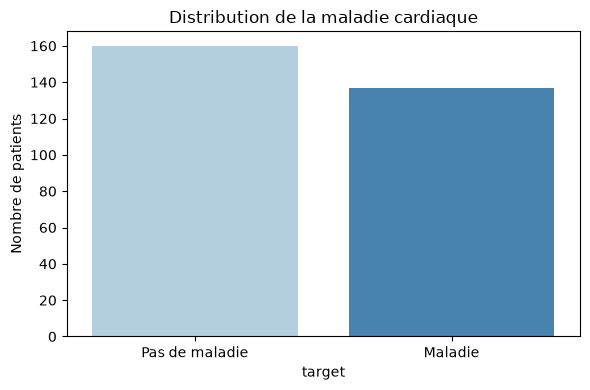

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# La variable cible originale a des valeurs 0,1,2,3,4
# En pratique on la binarise : 0 = pas de maladie, 1 = maladie
df['target'] = (df['target'] > 0).astype(int)

# Distribution
print("=== Distribution de la variable cible ===")
print(df['target'].value_counts())
print(f"\n{round(df['target'].mean()*100, 1)}% de cas positifs")

# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, hue='target', legend=False, palette='Blues')
plt.title('Distribution de la maladie cardiaque')
plt.xticks([0,1], ['Pas de maladie', 'Maladie'])
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.show()

## 1.3. Statistiques descriptives

In [3]:
# Convertir en numérique (certaines colonnes sont en object à cause des '?')
df = df.astype(float)

# Statistiques descriptives
print("=== Statistiques descriptives ===")
print(df.describe())

print("\n=== Types des colonnes ===")
print(df.dtypes)

print("\n=== Valeurs manquantes restantes ===")
print(df.isnull().sum())

=== Statistiques descriptives ===
              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    3.158249  131.693603  247.350168    0.144781   
std      9.049736    0.468500    0.964859   17.762806   51.997583    0.352474   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  243.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  276.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean     0.996633  149.599327    0.326599    1.055556    1.602694    0.676

## 1.4. Distribution des variables numériques

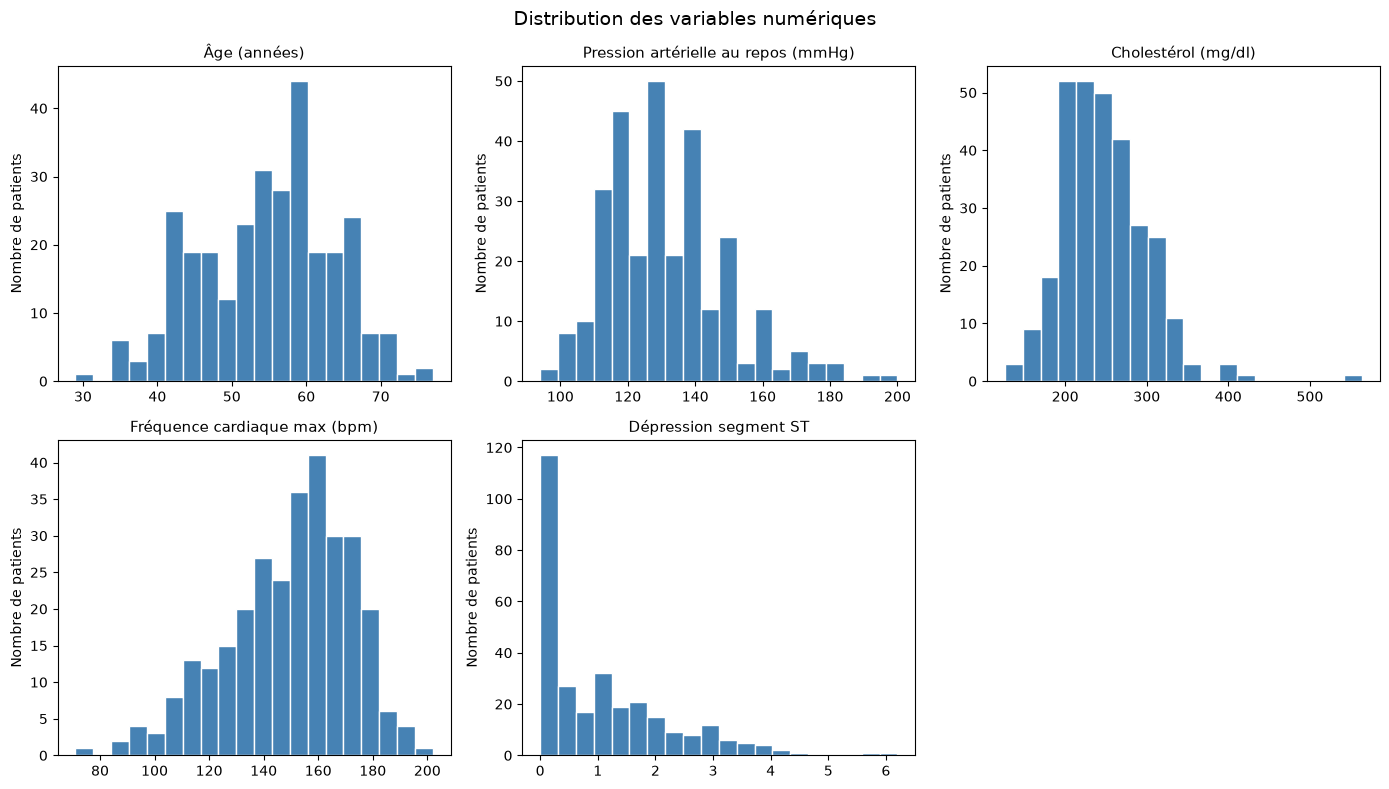

In [8]:
# --- Noms complets des variables pour l'affichage ---
num_cols_names = {
    'age': 'Âge (années)',
    'trestbps': 'Pression artérielle au repos (mmHg)',
    'chol': 'Cholestérol (mg/dl)',
    'thalach': 'Fréquence cardiaque max (bpm)',
    'oldpeak': 'Dépression segment ST'
}

# --- Créer une grille de 2 lignes x 3 colonnes pour accueillir les 5 graphiques ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Convertir la grille 2D en liste 1D pour itérer facilement
axes = axes.flatten()

# --- Tracer un histogramme par variable ---
for i, (col, name) in enumerate(num_cols_names.items()):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(name, fontsize=11)
    axes[i].set_ylabel('Nombre de patients')

# --- Supprimer le 6ème emplacement vide et afficher ---
fig.delaxes(axes[5])
plt.suptitle('Distribution des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

## 1.5. Matrice de corrélation

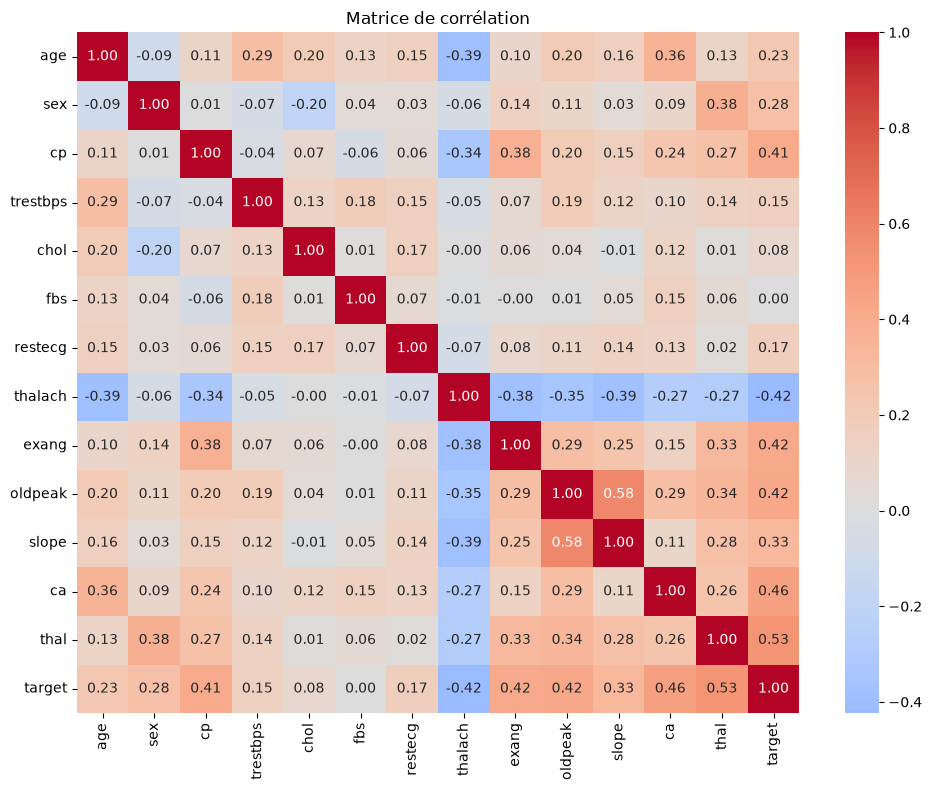

=== Corrélations avec la variable cible ===
target      1.000000
thal        0.526640
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64


In [9]:
# --- Calculer la matrice de corrélation entre toutes les variables ---
corr = df.corr()

# --- Afficher la heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

# --- Afficher les corrélations avec la cible uniquement ---
print("=== Corrélations avec la variable cible ===")
print(corr['target'].sort_values(ascending=False))

## 1.6. Distribution des variables par rapport à la cible

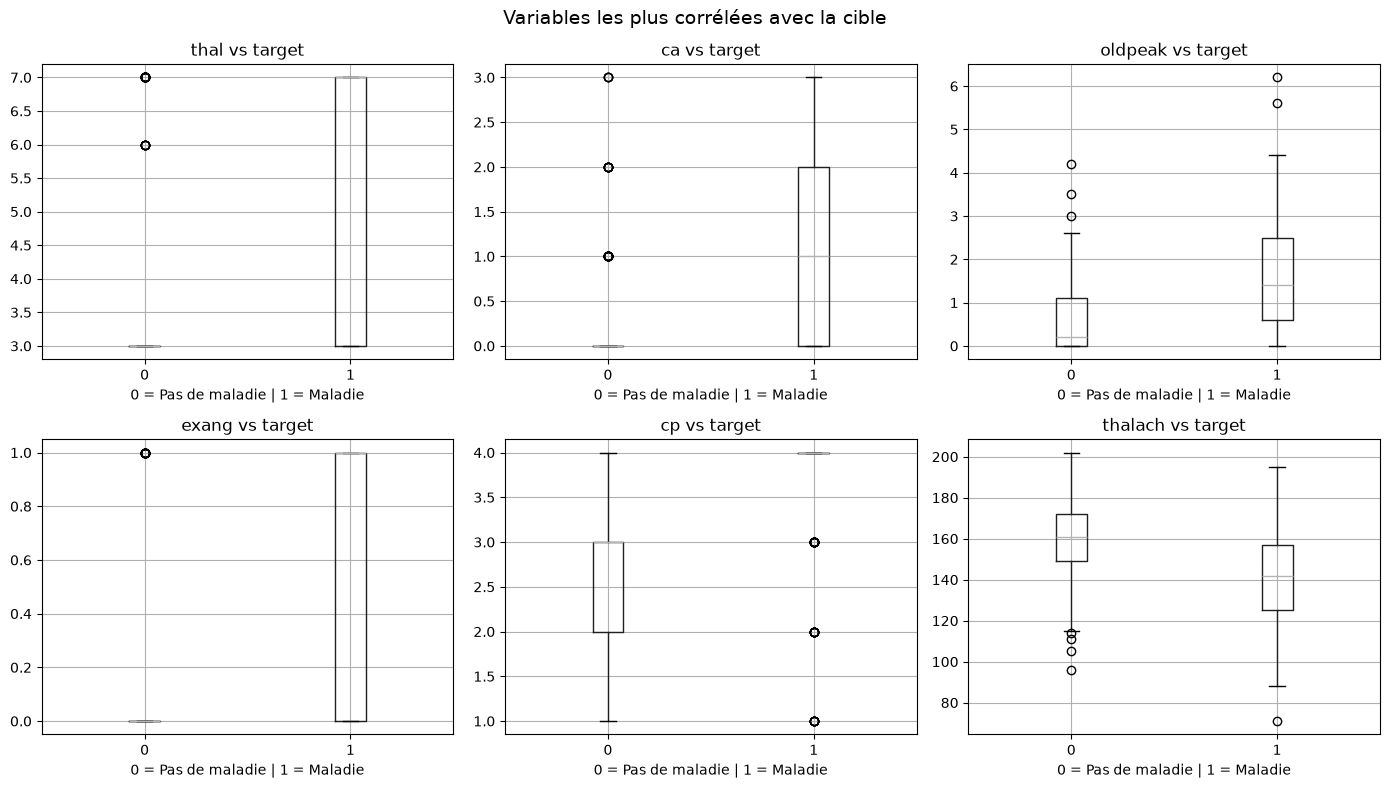

In [10]:
# --- Visualiser les variables les plus corrélées selon la cible ---
top_vars = ['thal', 'ca', 'oldpeak', 'exang', 'cp', 'thalach']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_vars):
    # Boxplot par classe cible
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(f'{col} vs target')
    axes[i].set_xlabel('0 = Pas de maladie | 1 = Maladie')

plt.suptitle('Variables les plus corrélées avec la cible', fontsize=14)
plt.tight_layout()
plt.show()